ANOVA analysis - vertical difference

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, levene, bartlett, anderson, normaltest

import pingouin as pg
from itertools import combinations
import matplotlib.pyplot as plt

In [2]:
# normality and homogeneity of variance tests for ANOVA assumptions
def check_anova_assumptions(df, group_col, metric_col, group_order=None):
    if group_order is None:
        group_order = df[group_col].unique()

    print(f"\n=== Normality test (D’Agostino and Pearson) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        stat, p = normaltest(data)
        result = "OK normal" if p > 0.05 else "not normal"
        print(f"{group.ljust(25)}:\tp = {p:.4f}\t→\t{result}")

    print(f"\n=== Normality test (Shapiro-Wilk) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        stat, p = shapiro(data)
        result = "OK normal" if p > 0.05 else "not normal"
        print(f"{group.ljust(25)}:\tp = {p:.4f}\t→\t{result}")

    print(f"\n=== Normality test (Anderson-Darling) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        result = anderson(data)
        stat = result.statistic
        crit_5 = result.critical_values[2]
        interpretation = "OK normal" if stat < crit_5 else "not normal"
        print(f"{group.ljust(25)}:\tA² = {stat:.4f},\t5% critical = {crit_5:.4f}\t→\t{interpretation}")

    print(f"\n=== Homogeneity of variance tests for {metric_col} ===")
    groups = [df[df[group_col] == group][metric_col] for group in group_order]

    stat_levene, p_levene = levene(*groups)
    result_levene = "OK equal variances" if p_levene > 0.05 else "unequal variances"
    print(f"Levene’s test  : p = {p_levene:.4f}\t→\t{result_levene}")

    stat_bartlett, p_bartlett = bartlett(*groups)
    result_bartlett = "OK equal variances" if p_bartlett > 0.05 else "unequal variances"
    print(f"Bartlett’s test: p = {p_bartlett:.4f}\t→\t{result_bartlett}")

    # Brown–Forsythe test (Levene with center='median')
    stat_bf, p_bf = levene(*groups, center='median')
    result_bf = "OK equal variances" if p_bf > 0.05 else "unequal variances"
    print(f"Brown–Forsythe : p = {p_bf:.4f}\t→\t{result_bf}")

In [3]:
def interpret_eta2(x: float) -> str:
    if x < 0.01:
        return "negligible"
    elif x < 0.06:
        return "small"
    elif x < 0.14:
        return "medium"
    else:
        return "large"

def interpret_d_like(x: float) -> str:
    ax = abs(x)
    if ax < 0.2:
        return "negligible"
    elif ax < 0.5:
        return "small"
    elif ax < 0.8:
        return "medium"
    else:
        return "large"

In [4]:
# ANOVA with eta squared, Games-Howell posthoc, and pairwise Hedges g effect sizes
def run_anova_full(df, group_col, metric_col, show_ci=True):
    # ===== Welch ANOVA =====
    print(f"\n=== Welch ANOVA for {metric_col} ===")
    welch = pg.welch_anova(dv=metric_col, between=group_col, data=df)
    print(welch.to_string(index=False))

    # Overall effect size (np2) interpretation
    if "np2" in welch.columns:
        np2 = float(welch.loc[0, "np2"])
        print(f"\nEffect size (partial η², np2) = {np2:.4f} → {interpret_eta2(np2)} effect")
    else:
        np2 = None
        print("\nEffect size: np2 not provided by Welch ANOVA output.")

    # ===== Games-Howell post-hoc =====
    print(f"\n=== Games-Howell post-hoc test for {metric_col} ===")
    gh = pg.pairwise_gameshowell(dv=metric_col, between=group_col, data=df).copy()
    print(gh.to_string(index=False))

    # ===== Pairwise effect sizes =====
    print(f"\n=== Pairwise effect sizes for {metric_col} (Hedges' g) ===")
    group_labels = list(pd.unique(df[group_col]))
    label_width = max(len(str(g)) for g in group_labels) + 2

    for g1, g2 in combinations(group_labels, 2):
        x = df.loc[df[group_col] == g1, metric_col].to_numpy()
        y = df.loc[df[group_col] == g2, metric_col].to_numpy()

        g = float(pg.compute_effsize(x, y, eftype="hedges"))
        effect = interpret_d_like(g)

        line = (
            f"{str(g1).ljust(label_width)} vs {str(g2).ljust(label_width)}:"
            f" g = {g:.4f} → {effect} effect"
        )

        if show_ci:
            ci = pg.compute_bootci(
                x, y,
                func=lambda a, b: pg.compute_effsize(a, b, eftype="hedges"),
                confidence=0.95,
                method="percentile",
            )
            line += f"   95% CI [{ci[0]:.4f}, {ci[1]:.4f}]"

        print(line)

## Time independent - Back

In [20]:
model = "time independent Back CO2 VD"
single_top_co2 = pd.read_csv("../../analysis_sensor_position/_timeindep_results_raw/case_room1_backtop_state_timeindep_co2.csv")
single_low_co2 = pd.read_csv("../../analysis_sensor_position/_timeindep_results_raw/case_room1_backlow_state_timeindep_co2.csv")
dual_co2_only = pd.read_csv("../_timeindep_results_raw/case_room1_back_state_timeindep_co2only.csv")
dual_VD = pd.read_csv("../_timeindep_results_raw/case_room1_back_state_timeindep_VD.csv")
dual_VD_co2 = pd.read_csv("../_timeindep_results_raw/case_room1_back_state_timeindep_VDco2.csv")

In [21]:
single_top_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.869597,0.019973,0.818930,0.855967,0.868313,0.884774,0.925926
f1_weighted,250.0,0.869275,0.019987,0.818930,0.855775,0.869052,0.883295,0.925926
balanced_acc,250.0,0.852761,0.022493,0.785238,0.837511,0.853857,0.866880,0.919012
auc,250.0,0.932694,0.014940,0.888804,0.923133,0.932999,0.943757,0.967931
model_weights.random_forest,250.0,1.793039,0.376278,0.843843,1.533724,1.795923,2.020654,3.030745
model_weights.bagging_svc,250.0,0.909599,0.228069,0.282863,0.750351,0.898959,1.065743,1.559134
model_weights.bagging_knn,250.0,1.354812,0.331210,0.262218,1.116187,1.365029,1.588906,2.309395
model_weights.gradient_boosting,250.0,1.415840,0.355379,0.362884,1.172661,1.423217,1.670289,2.494862


In [22]:
single_low_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.865547,0.020764,0.806584,0.851852,0.868313,0.880658,0.930041
f1_weighted,250.0,0.864709,0.021054,0.804653,0.849468,0.866711,0.879591,0.928472
balanced_acc,250.0,0.845302,0.024135,0.780725,0.827112,0.847210,0.862265,0.900055
auc,250.0,0.932465,0.015964,0.889862,0.922031,0.932348,0.944679,0.971914
model_weights.random_forest,250.0,2.837346,0.334240,1.805919,2.622974,2.846261,3.074338,3.747373
model_weights.bagging_svc,250.0,-0.025029,0.457282,-1.557340,-0.290968,-0.018596,0.269795,1.379667
model_weights.bagging_knn,250.0,1.451378,0.284139,0.653054,1.254907,1.452736,1.639612,2.309607
model_weights.gradient_boosting,250.0,1.296536,0.349891,0.123896,1.053972,1.295861,1.529697,2.096356


In [23]:
dual_co2_only.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,1.245000e+02,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,1.245000e+02,186.750000,249.000000
accuracy,250.0,0.883210,0.021040,0.814815,0.868313,8.847737e-01,0.897119,0.934156
f1_weighted,250.0,0.883311,0.020998,0.815046,0.869797,8.849152e-01,0.897692,0.934156
balanced_acc,250.0,0.871254,0.023861,0.799845,0.854056,8.733537e-01,0.887604,0.930323
auc,250.0,0.947848,0.013633,0.906014,0.938277,9.480428e-01,0.958024,0.984901
model_weights.random_forest,250.0,3.310896,0.378497,2.240469,3.041199,3.318896e+00,3.586780,4.216543
model_weights.bagging_svc,250.0,0.702807,0.199614,0.141725,0.589362,7.129837e-01,0.821618,1.412119
model_weights.bagging_knn,250.0,0.590792,0.289856,-0.121470,0.396363,5.788112e-01,0.789773,1.392919
model_weights.gradient_boosting,250.0,1.031181,0.330208,0.193470,0.814581,9.895508e-01,1.283293,1.853386


In [24]:
dual_VD.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.790189,0.023538,0.732510,0.773663,0.792181,0.806584,0.847737
f1_weighted,250.0,0.784759,0.024658,0.724238,0.769510,0.787014,0.803358,0.842774
balanced_acc,250.0,0.746484,0.027388,0.677273,0.725207,0.748719,0.768409,0.810234
auc,250.0,0.848345,0.023055,0.797018,0.830646,0.848392,0.865144,0.903519
model_weights.random_forest,250.0,1.540155,0.428308,0.580470,1.222102,1.518178,1.837021,2.566210
model_weights.bagging_svc,250.0,0.506384,0.232647,-0.069684,0.353506,0.511979,0.662756,1.190576
model_weights.bagging_knn,250.0,0.179039,0.307679,-0.830914,-0.034725,0.158449,0.402720,0.938389
model_weights.gradient_boosting,250.0,1.422338,0.379888,0.497943,1.178428,1.416314,1.678407,2.314281


In [25]:
dual_VD_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.899473,0.019860,0.847737,0.884774,0.901235,0.913580,0.954733
f1_weighted,250.0,0.899751,0.019823,0.848288,0.885842,0.901477,0.913874,0.954806
balanced_acc,250.0,0.891244,0.022701,0.828873,0.876057,0.892728,0.907852,0.953577
auc,250.0,0.955115,0.012734,0.917790,0.946118,0.955704,0.965132,0.988656
model_weights.random_forest,250.0,3.441789,0.407370,2.403186,3.207192,3.422430,3.678462,4.396410
model_weights.bagging_svc,250.0,0.409966,0.262589,-0.254750,0.237729,0.418933,0.601636,1.145283
model_weights.bagging_knn,250.0,0.484360,0.304911,-0.318033,0.278727,0.502830,0.694468,1.258799
model_weights.gradient_boosting,250.0,1.664455,0.329582,0.808378,1.454143,1.665147,1.868688,2.533351


In [26]:
single_top_co2['case'] = 'single_top_co2'
single_low_co2['case'] = 'single_low_co2'
dual_co2_only['case'] = 'dual_co2_only'
dual_VD['case'] = 'dual_VD'
dual_VD_co2['case'] = 'dual_VD_co2'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        single_top_co2[metrics],
        single_low_co2[metrics],
        dual_co2_only[metrics],
        dual_VD[metrics],
        dual_VD_co2[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1250 non-null   object 
 1   accuracy      1250 non-null   float64
 2   f1_weighted   1250 non-null   float64
 3   balanced_acc  1250 non-null   float64
 4   auc           1250 non-null   float64
dtypes: float64(4), object(1)
memory usage: 49.0+ KB


In [27]:
case_order = ['single_top_co2', 'single_low_co2', 'dual_co2_only', 'dual_VD', 'dual_VD_co2']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,single_top_co2,single_top_co2,single_top_co2,single_top_co2,single_top_co2
accuracy,0.884774,0.876543,0.835391,0.876543,0.868313
f1_weighted,0.883307,0.875365,0.835809,0.875709,0.871356
balanced_acc,0.861411,0.854066,0.822656,0.853873,0.853279
auc,0.936059,0.945407,0.899719,0.938267,0.930672
x,0,0,0,0,0
x_jitter,-0.032095,-0.077205,0.050466,-0.088173,0.06761


### plot

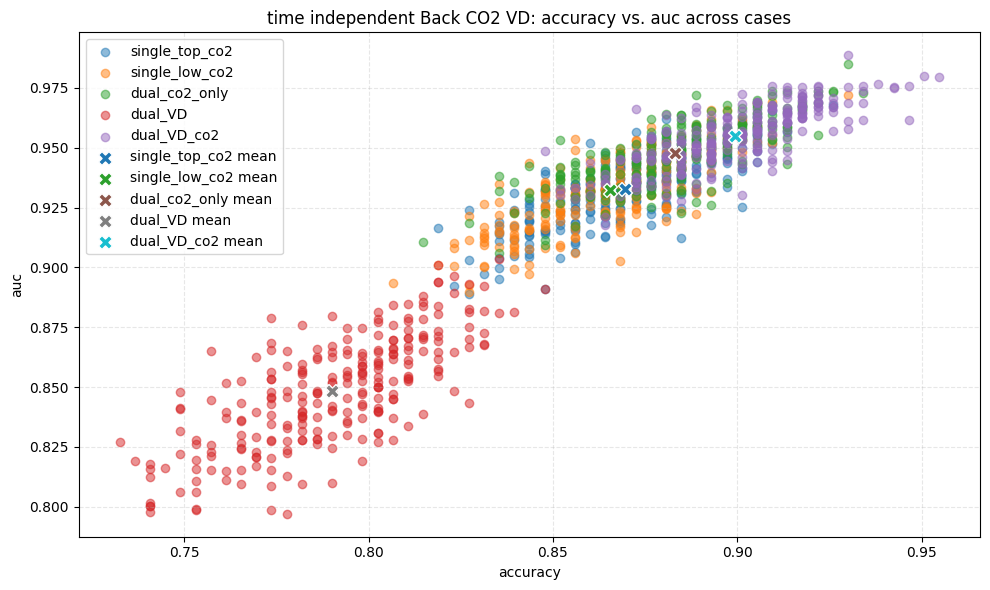

In [28]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

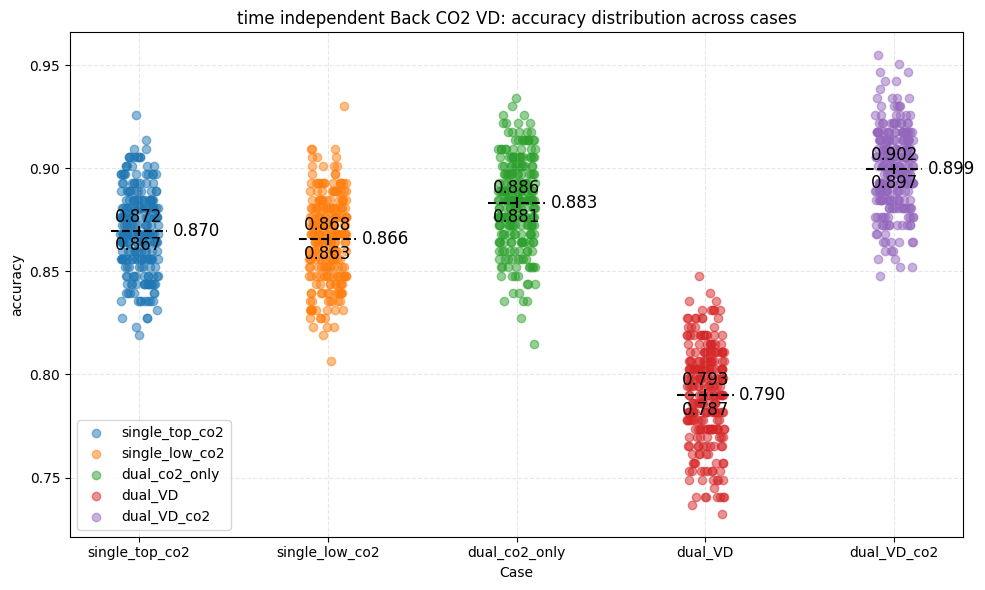

In [30]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

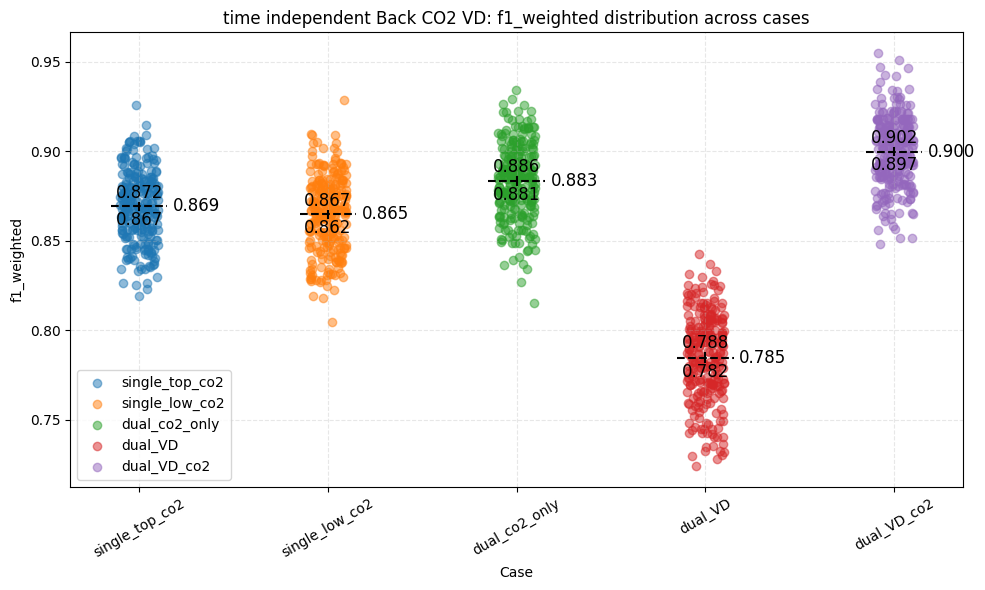

In [31]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order, rotation=30)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

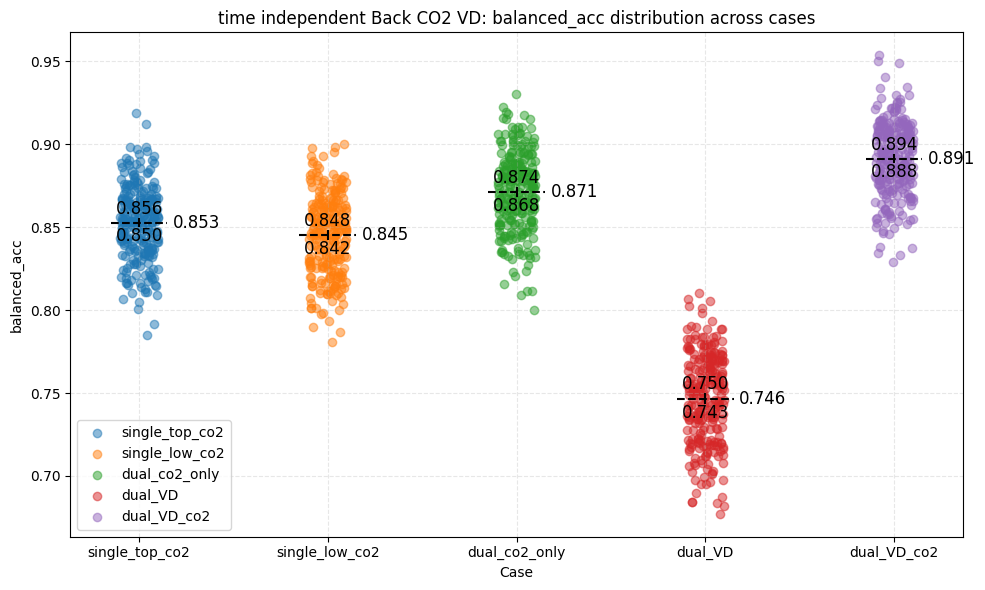

In [32]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

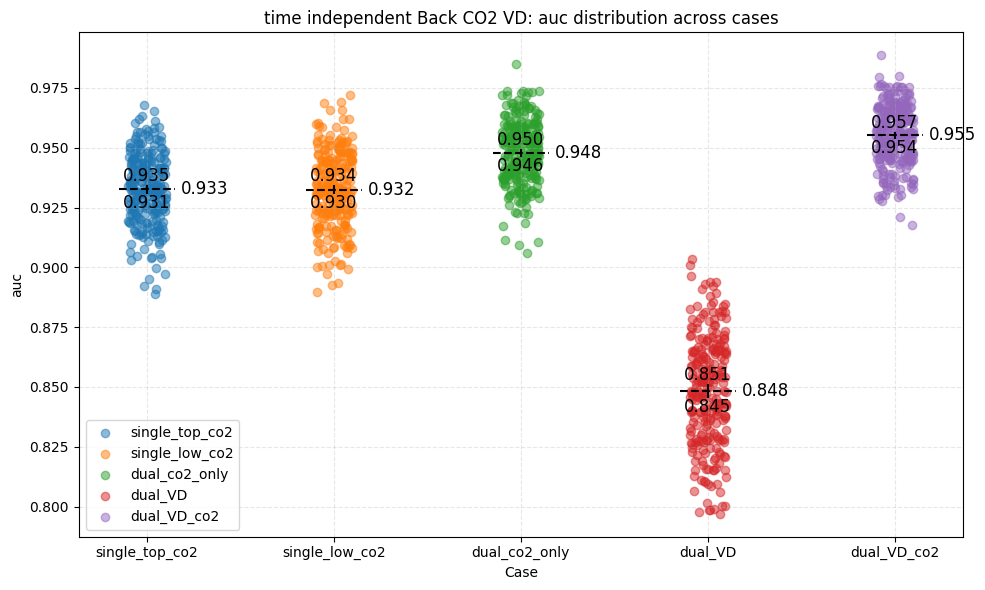

In [33]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent Back CO2 VD

=== Normality test (D’Agostino and Pearson) for accuracy ===
single_top_co2           :	p = 0.1878	→	OK normal
single_low_co2           :	p = 0.4743	→	OK normal
dual_co2_only            :	p = 0.3478	→	OK normal
dual_VD                  :	p = 0.0357	→	not normal
dual_VD_co2              :	p = 0.9000	→	OK normal

=== Normality test (Shapiro-Wilk) for accuracy ===
single_top_co2           :	p = 0.1281	→	OK normal
single_low_co2           :	p = 0.1107	→	OK normal
dual_co2_only            :	p = 0.1922	→	OK normal
dual_VD                  :	p = 0.0104	→	not normal
dual_VD_co2              :	p = 0.2555	→	OK normal

=== Normality test (Anderson-Darling) for accuracy ===
single_top_co2           :	A² = 0.7538,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 0.9284,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 0.6424,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 1.1278,	5% critical = 0.7750	→	not normal
dual_

In [35]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent Back CO2 VD

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
single_top_co2           :	p = 0.2779	→	OK normal
single_low_co2           :	p = 0.3578	→	OK normal
dual_co2_only            :	p = 0.3501	→	OK normal
dual_VD                  :	p = 0.0293	→	not normal
dual_VD_co2              :	p = 0.8667	→	OK normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
single_top_co2           :	p = 0.6119	→	OK normal
single_low_co2           :	p = 0.2131	→	OK normal
dual_co2_only            :	p = 0.5133	→	OK normal
dual_VD                  :	p = 0.0192	→	not normal
dual_VD_co2              :	p = 0.5233	→	OK normal

=== Normality test (Anderson-Darling) for f1_weighted ===
single_top_co2           :	A² = 0.2768,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 0.7029,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.3211,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.8803,	5% critical = 0.7750	→	not norm

In [36]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent Back CO2 VD

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
single_top_co2           :	p = 0.7279	→	OK normal
single_low_co2           :	p = 0.0749	→	OK normal
dual_co2_only            :	p = 0.2874	→	OK normal
dual_VD                  :	p = 0.0385	→	not normal
dual_VD_co2              :	p = 0.4218	→	OK normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
single_top_co2           :	p = 0.8436	→	OK normal
single_low_co2           :	p = 0.1456	→	OK normal
dual_co2_only            :	p = 0.4399	→	OK normal
dual_VD                  :	p = 0.0363	→	not normal
dual_VD_co2              :	p = 0.0773	→	OK normal

=== Normality test (Anderson-Darling) for balanced_acc ===
single_top_co2           :	A² = 0.3364,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 0.6883,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.3512,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.9341,	5% critical = 0.7750	→	not n

In [37]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent Back CO2 VD

=== Normality test (D’Agostino and Pearson) for auc ===
single_top_co2           :	p = 0.1948	→	OK normal
single_low_co2           :	p = 0.3023	→	OK normal
dual_co2_only            :	p = 0.3056	→	OK normal
dual_VD                  :	p = 0.0552	→	OK normal
dual_VD_co2              :	p = 0.0778	→	OK normal

=== Normality test (Shapiro-Wilk) for auc ===
single_top_co2           :	p = 0.2640	→	OK normal
single_low_co2           :	p = 0.3287	→	OK normal
dual_co2_only            :	p = 0.2006	→	OK normal
dual_VD                  :	p = 0.1508	→	OK normal
dual_VD_co2              :	p = 0.0361	→	not normal

=== Normality test (Anderson-Darling) for auc ===
single_top_co2           :	A² = 0.3180,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 0.5119,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.3907,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.4266,	5% critical = 0.7750	→	OK normal
dual_VD_co2            

### ANOVA

In [38]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent Back CO2 VD

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 621.987621 866.844042 1.172161e-252 0.761929

Effect size (partial η², np2) = 0.7619 → large effect

=== Games-Howell post-hoc test for accuracy ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.790189 0.899473 -0.109284 0.001948 -56.107497 484.285416 3.316236e-13 -5.010845
       dual_VD  dual_co2_only 0.790189 0.883210 -0.093021 0.001997 -46.586973 491.862406 6.772360e-15 -4.160587
       dual_VD single_low_co2 0.790189 0.865547 -0.075358 0.001985 -37.961696 490.370078 1.576517e-13 -3.390281
       dual_VD single_top_co2 0.790189 0.869597 -0.079407 0.001952 -40.671773 485.150843 4.585221e-14 -3.632313
   dual_VD_co2  dual_co2_only 0.899473 0.883210  0.016263 0.001830   8.887734 496.349748 1.719735e-13  0.793745
   dual_VD_co2 single_low_co2 0.899473 0.86

In [39]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent Back CO2 VD

=== Welch ANOVA for f1_weighted ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 621.700617 901.044036 4.935366e-257 0.776205

Effect size (partial η², np2) = 0.7762 → large effect

=== Games-Howell post-hoc test for f1_weighted ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.784759 0.899751 -0.114992 0.002001 -57.467701 476.021893 6.872281e-14 -5.132323
       dual_VD  dual_co2_only 0.784759 0.883311 -0.098552 0.002048 -48.112219 485.674873 0.000000e+00 -4.296804
       dual_VD single_low_co2 0.784759 0.864709 -0.079951 0.002051 -38.988053 486.058317 1.378897e-13 -3.481943
       dual_VD single_top_co2 0.784759 0.869275 -0.084517 0.002008 -42.100391 477.537789 0.000000e+00 -3.759900
   dual_VD_co2  dual_co2_only 0.899751 0.883311  0.016440 0.001826   9.001500 496.356643 0.000000e+00  0.803906
   dual_VD_co2 single_low_co2 0.89975

In [40]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent Back CO2 VD

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2           F         p-unc      np2
  case      4 621.829798 1144.482756 4.768910e-285 0.811437

Effect size (partial η², np2) = 0.8114 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.746484 0.891244 -0.144760 0.002250 -64.342480 481.424857 0.000000e+00 -5.746295
       dual_VD  dual_co2_only 0.746484 0.871254 -0.124770 0.002297 -54.310606 488.822856 2.913225e-13 -4.850369
       dual_VD single_low_co2 0.746484 0.845302 -0.098818 0.002309 -42.800493 490.245918 0.000000e+00 -3.822424
       dual_VD single_top_co2 0.746484 0.852761 -0.106276 0.002241 -47.413835 479.861730 3.310685e-13 -4.234432
   dual_VD_co2  dual_co2_only 0.891244 0.871254  0.019989 0.002083   9.596808 496.768023 0.000000e+00  0.857071
   dual_VD_co2 single_low_co2 0.8

In [41]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent Back CO2 VD

=== Welch ANOVA for auc ===
Source  ddof1     ddof2           F         p-unc      np2
  case      4 618.18182 1093.678256 1.037109e-278 0.845599

Effect size (partial η², np2) = 0.8456 → large effect

=== Games-Howell post-hoc test for auc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.848345 0.955115 -0.106770 0.001666 -64.097559 387.986808 0.000000e+00 -5.724422
       dual_VD  dual_co2_only 0.848345 0.947848 -0.099503 0.001694 -58.739535 404.163742 3.470557e-13 -5.245907
       dual_VD single_low_co2 0.848345 0.932465 -0.084120 0.001774 -47.430231 443.144707 4.762857e-13 -4.235897
       dual_VD single_top_co2 0.848345 0.932694 -0.084349 0.001738 -48.546394 426.776947 0.000000e+00 -4.335579
   dual_VD_co2  dual_co2_only 0.955115 0.947848  0.007267 0.001180   6.159287 495.699163 1.509981e-08  0.550073
   dual_VD_co2 single_low_co2 0.955115 0.932465  0.02

## Time series - Back

In [42]:
model = "time series Back CO2 VD"
single_top_co2 = pd.read_csv("../../analysis_sensor_position/_timeseries_results_raw/case_room1_backtop_state_timeseries_co2.csv")
single_low_co2 = pd.read_csv("../../analysis_sensor_position/_timeseries_results_raw/case_room1_backlow_state_timeseries_co2.csv")
dual_co2_only = pd.read_csv("../_timeseries_results_raw/case_room1_back_state_timeseries_co2only.csv")
dual_VD = pd.read_csv("../_timeseries_results_raw/case_room1_back_state_timeseries_VD.csv")
dual_VD_co2 = pd.read_csv("../_timeseries_results_raw/case_room1_back_state_timeseries_VDco2.csv")

In [43]:
single_top_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.842630,0.054333,0.579909,0.831050,0.853881,0.867580,0.917808
f1,250.0,0.780029,0.143208,0.000000,0.779485,0.813953,0.833092,0.900000
balanced_acc,250.0,0.825259,0.066634,0.500000,0.814832,0.841065,0.856577,0.912658
auc,250.0,0.916168,0.018180,0.849795,0.906517,0.917922,0.928107,0.959517
feature_importance.backtop_CO2_scaled,250.0,0.131887,0.147771,-0.080822,0.019749,0.068265,0.233447,0.523744
feature_importance.backtop_CO2_fd1_scaled,250.0,0.093806,0.072474,-0.019635,0.023858,0.092237,0.150457,0.300000
feature_importance.backtop_CO2_fd2_scaled,250.0,0.075200,0.067965,-0.044749,0.014384,0.060046,0.124886,0.261187
feature_importance.backtop_CO2_fd3_scaled,250.0,0.076007,0.067173,-0.036073,0.015639,0.068265,0.118950,0.317352


In [44]:
single_low_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.859769,0.034415,0.742222,0.844444,0.862222,0.888889,0.924444
f1,250.0,0.831801,0.039089,0.582090,0.809524,0.827586,0.862678,0.909091
balanced_acc,250.0,0.857928,0.032022,0.700678,0.837896,0.853710,0.883929,0.924363
auc,250.0,0.909109,0.009869,0.832788,0.905075,0.911000,0.915311,0.927100
feature_importance.backlow_CO2_scaled,250.0,0.322075,0.099738,0.007556,0.276889,0.367111,0.390556,0.450667
feature_importance.backlow_CO2_fd1_scaled,250.0,0.086395,0.061555,-0.001333,0.031556,0.080222,0.127111,0.294667
feature_importance.backlow_CO2_fd2_scaled,250.0,0.081721,0.060209,-0.003111,0.024333,0.075333,0.130556,0.285333
feature_importance.backlow_CO2_fd3_scaled,250.0,0.076110,0.061124,-0.008889,0.021222,0.070444,0.118556,0.325333


In [45]:
dual_co2_only.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.869626,0.036359,0.694064,0.858447,0.872146,0.894977,0.922374
f1,250.0,0.845775,0.034469,0.717300,0.827586,0.846614,0.872928,0.909091
balanced_acc,250.0,0.866364,0.032441,0.725736,0.851934,0.867853,0.890395,0.922586
auc,250.0,0.915923,0.008270,0.868709,0.912316,0.916980,0.920811,0.930846
feature_importance.backlow_CO2_scaled,250.0,0.189947,0.126097,-0.022374,0.064498,0.208676,0.309475,0.391781
feature_importance.backlow_CO2_fd1_scaled,250.0,0.021600,0.028090,-0.017808,-0.000457,0.013699,0.035959,0.150228
feature_importance.backlow_CO2_fd2_scaled,250.0,0.017766,0.027224,-0.029224,-0.001370,0.009817,0.032877,0.154795
feature_importance.backlow_CO2_fd3_scaled,250.0,0.015616,0.027319,-0.036986,-0.002283,0.008676,0.027397,0.173973


In [46]:
dual_VD.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.721589,0.098396,0.579909,0.586758,0.748858,0.803653,0.872146
f1,250.0,0.492604,0.323135,0.000000,0.030612,0.648447,0.764247,0.858586
balanced_acc,250.0,0.684860,0.129967,0.500000,0.508152,0.727020,0.792323,0.879279
auc,250.0,0.834836,0.092003,0.430332,0.806488,0.869480,0.897210,0.946080
feature_importance.back_CO2_vd_scaled,250.0,-0.009726,0.021219,-0.150685,-0.021347,-0.002283,0.000000,0.070776
feature_importance.back_CO2_vd_fd1_scaled,250.0,0.023101,0.036082,-0.034703,0.000000,0.011187,0.032420,0.242922
feature_importance.back_CO2_vd_fd2_scaled,250.0,0.047468,0.062370,-0.005023,0.000000,0.025342,0.070091,0.342466
feature_importance.back_CO2_vd_fd3_scaled,250.0,0.055043,0.073340,-0.004566,0.000000,0.030822,0.075685,0.416438


In [47]:
dual_VD_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,1.245000e+02,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,1.245000e+02,186.750000,249.000000
accuracy,250.0,0.863236,0.023474,0.693333,0.857778,8.622222e-01,0.871111,0.924444
f1,250.0,0.823316,0.030950,0.642857,0.813953,8.222394e-01,0.834785,0.909091
balanced_acc,250.0,0.850754,0.024689,0.728874,0.842841,8.495423e-01,0.859452,0.924363
auc,250.0,0.913596,0.008736,0.887218,0.909039,9.137790e-01,0.918601,0.940830
feature_importance.back_CO2_vd_scaled,250.0,-0.001872,0.011875,-0.074222,-0.003111,-1.110223e-16,0.002667,0.024889
feature_importance.back_CO2_vd_fd1_scaled,250.0,-0.001291,0.006035,-0.028000,-0.003556,-6.666667e-04,0.000889,0.024444
feature_importance.back_CO2_vd_fd2_scaled,250.0,-0.001495,0.006348,-0.021778,-0.004778,-1.111111e-03,0.001333,0.026667
feature_importance.back_CO2_vd_fd3_scaled,250.0,-0.002604,0.007050,-0.028444,-0.005333,-1.333333e-03,0.000889,0.020000


In [48]:
single_top_co2['case'] = 'single_top_co2'
single_low_co2['case'] = 'single_low_co2'
dual_co2_only['case'] = 'dual_co2_only'
dual_VD['case'] = 'dual_VD'
dual_VD_co2['case'] = 'dual_VD_co2'

metrics = ["case", "accuracy", "f1", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        single_top_co2[metrics],
        single_low_co2[metrics],
        dual_co2_only[metrics],
        dual_VD[metrics],
        dual_VD_co2[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1250 non-null   object 
 1   accuracy      1250 non-null   float64
 2   f1            1250 non-null   float64
 3   balanced_acc  1250 non-null   float64
 4   auc           1250 non-null   float64
dtypes: float64(4), object(1)
memory usage: 49.0+ KB


In [49]:
case_order = ['single_top_co2', 'single_low_co2', 'dual_co2_only', 'dual_VD', 'dual_VD_co2']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,single_top_co2,single_top_co2,single_top_co2,single_top_co2,single_top_co2
accuracy,0.826484,0.885845,0.835616,0.885845,0.86758
f1,0.75,0.858757,0.775,0.857143,0.828402
balanced_acc,0.797972,0.87761,0.813334,0.876113,0.852876
auc,0.941886,0.93367,0.927422,0.907651,0.92785
x,0,0,0,0,0
x_jitter,0.075874,0.018517,-0.052424,-0.061932,-0.011385


### plot

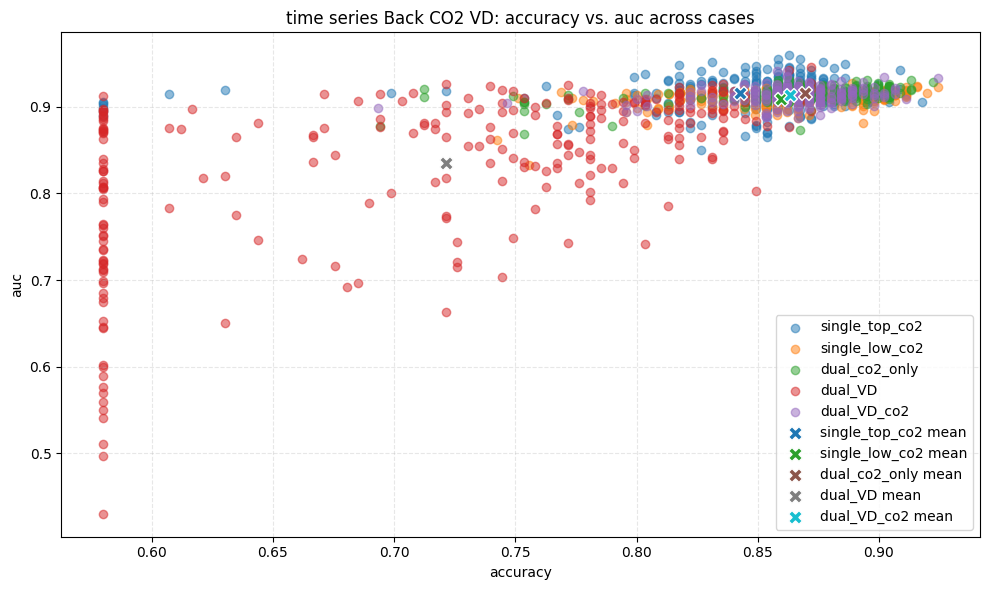

In [50]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

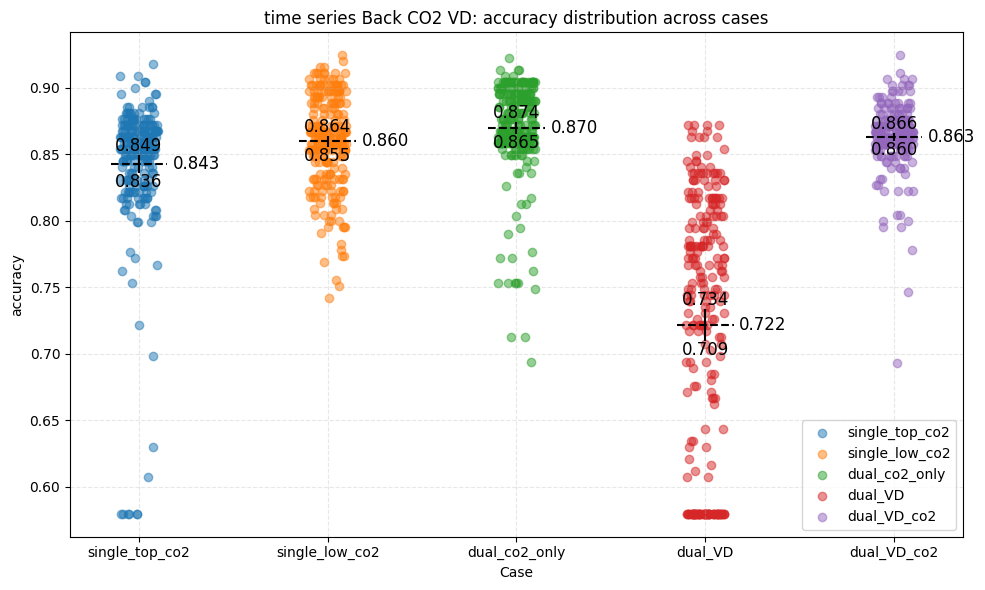

In [51]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

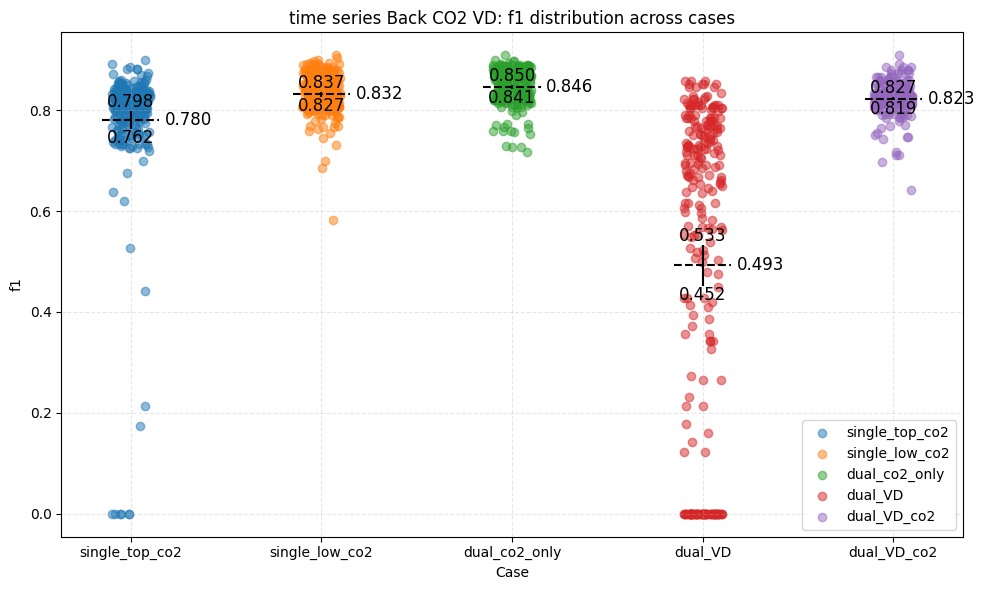

In [52]:
# plot f1 score
metric = "f1"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

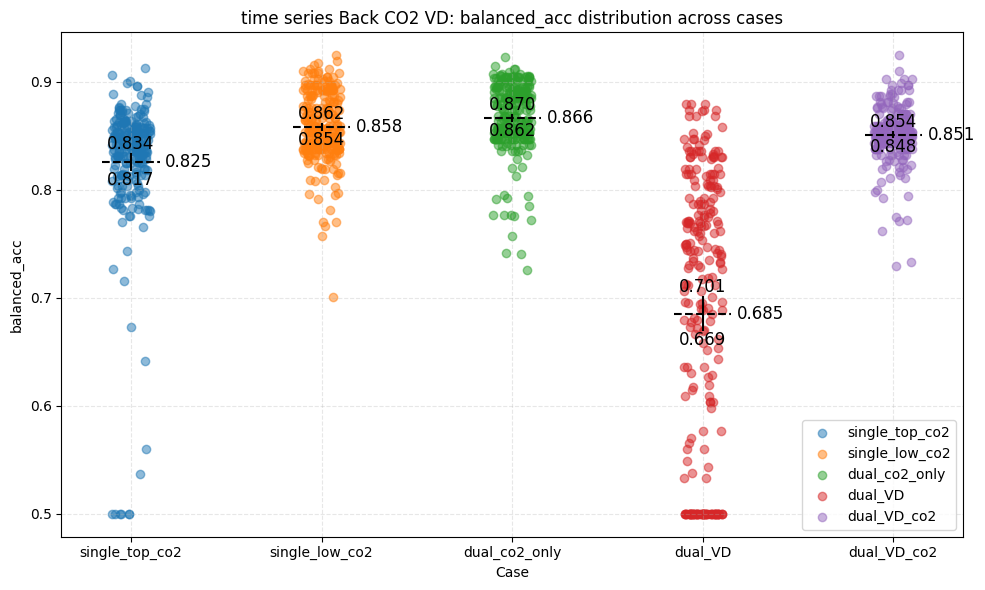

In [53]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

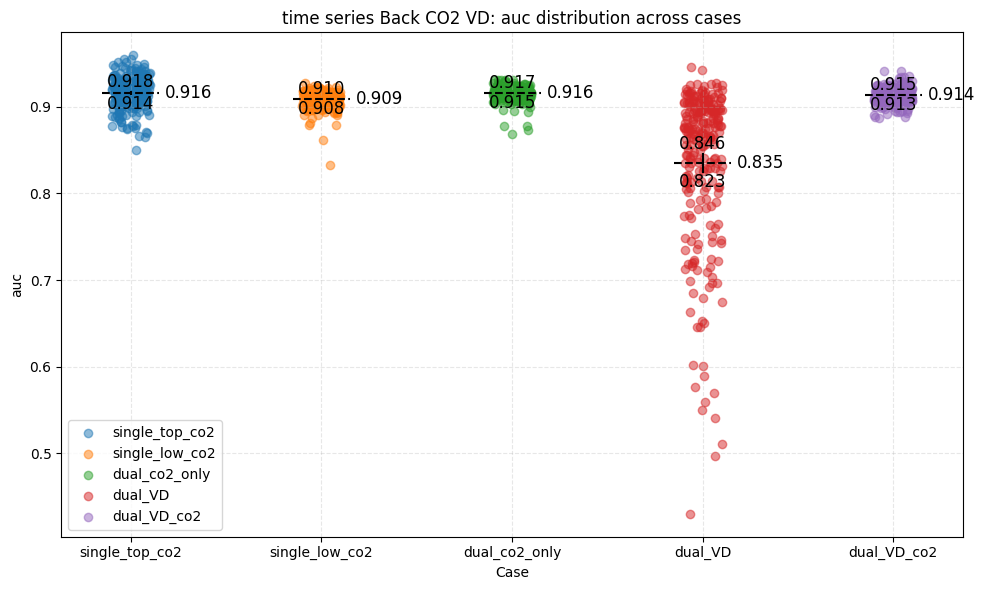

In [54]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time series Back CO2 VD

=== Normality test (D’Agostino and Pearson) for accuracy ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0001	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
single_top_co2           :	A² = 24.9425,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 2.4325,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 14.0641,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 10.9972,	5% critical = 0.7750	→	not norm

In [56]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1',
    group_order=case_order
)

time series Back CO2 VD

=== Normality test (D’Agostino and Pearson) for f1 ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for f1 ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for f1 ===
single_top_co2           :	A² = 44.4138,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 2.9616,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 4.3214,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 19.5348,	5% critical = 0.7750	→	not normal
dual_VD_co2     

In [57]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time series Back CO2 VD

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for balanced_acc ===
single_top_co2           :	A² = 25.7830,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 2.3389,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 6.0198,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 11.1222,	5% critical = 0.7750

In [58]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time series Back CO2 VD

=== Normality test (D’Agostino and Pearson) for auc ===
single_top_co2           :	p = 0.0011	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0172	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
single_top_co2           :	p = 0.0041	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0020	→	not normal

=== Normality test (Anderson-Darling) for auc ===
single_top_co2           :	A² = 1.0334,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 6.6379,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 5.7462,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 14.4396,	5% critical = 0.7750	→	not normal
dual_VD_co2   

### ANOVA

In [59]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time series Back CO2 VD

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2          F        p-unc      np2
  case      4 600.704272 134.336103 6.412394e-82 0.497356

Effect size (partial η², np2) = 0.4974 → large effect

=== Games-Howell post-hoc test for accuracy ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.721589 0.863236 -0.141647 0.006398 -22.140031 277.251376 0.000000e+00 -1.977281
       dual_VD  dual_co2_only 0.721589 0.869626 -0.148037 0.006634 -22.313487 315.755239 0.000000e+00 -1.992772
       dual_VD single_low_co2 0.721589 0.859769 -0.138180 0.006593 -20.959282 309.022320 1.130207e-13 -1.871830
       dual_VD single_top_co2 0.721589 0.842630 -0.121041 0.007109 -17.026883 387.927721 6.550316e-14 -1.520636
   dual_VD_co2  dual_co2_only 0.863236 0.869626 -0.006390 0.002737  -2.334528 425.846927 1.360579e-01 -0.208492
   dual_VD_co2 single_low_co2 0.863236 0.859769  0

In [60]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1'
)

time series Back CO2 VD

=== Welch ANOVA for f1 ===
Source  ddof1     ddof2         F        p-unc      np2
  case      4 598.17312 91.500938 1.120398e-60 0.408024

Effect size (partial η², np2) = 0.4080 → large effect

=== Games-Howell post-hoc test for f1 ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.492604 0.823316 -0.330712 0.020530 -16.108420 253.568102 0.000000e+00 -1.438610
       dual_VD  dual_co2_only 0.492604 0.845775 -0.353170 0.020553 -17.183559 254.665700 0.000000e+00 -1.534628
       dual_VD single_low_co2 0.492604 0.831801 -0.339197 0.020586 -16.477185 256.285732 3.463896e-14 -1.471544
       dual_VD single_top_co2 0.492604 0.780029 -0.287424 0.022354 -12.857885 343.179555 1.326717e-13 -1.148311
   dual_VD_co2  dual_co2_only 0.823316 0.845775 -0.022458 0.002930  -7.665358 492.334294 9.783285e-13 -0.684577
   dual_VD_co2 single_low_co2 0.823316 0.831801 -0.008485 0.003153

In [61]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time series Back CO2 VD

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2          F        p-unc      np2
  case      4 601.768018 127.525085 8.320651e-79 0.487768

Effect size (partial η², np2) = 0.4878 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.684860 0.850754 -0.165894 0.008367 -19.827547 266.947959 1.062483e-13 -1.770758
       dual_VD  dual_co2_only 0.684860 0.866364 -0.181504 0.008472 -21.423813 279.908439 8.804069e-14 -1.913317
       dual_VD single_low_co2 0.684860 0.857928 -0.173068 0.008466 -20.443478 279.120220 3.819167e-14 -1.825765
       dual_VD single_top_co2 0.684860 0.825259 -0.140399 0.009237 -15.199213 371.444538 1.401101e-13 -1.357411
   dual_VD_co2  dual_co2_only 0.850754 0.866364 -0.015610 0.002578  -6.054039 464.982664 2.908022e-08 -0.540674
   dual_VD_co2 single_low_co2 0.850754 0.8

In [62]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time series Back CO2 VD

=== Welch ANOVA for auc ===
Source  ddof1      ddof2         F        p-unc      np2
  case      4 604.456507 64.426078 2.238894e-45 0.357467

Effect size (partial η², np2) = 0.3575 → large effect

=== Games-Howell post-hoc test for auc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.834836 0.913596 -0.078760 0.005845 -13.474904 253.489517 0.000000e+00 -1.203416
       dual_VD  dual_co2_only 0.834836 0.915923 -0.081087 0.005842 -13.879405 253.023876 1.854072e-14 -1.239541
       dual_VD single_low_co2 0.834836 0.909109 -0.074273 0.005852 -12.691556 254.730023 0.000000e+00 -1.133457
       dual_VD single_top_co2 0.834836 0.916168 -0.081332 0.005931 -13.712424 268.416401 0.000000e+00 -1.224628
   dual_VD_co2  dual_co2_only 0.913596 0.915923 -0.002327 0.000761  -3.058109 496.514214 1.979546e-02 -0.273113
   dual_VD_co2 single_low_co2 0.913596 0.909109  0.004487 0.00

## Time independent - Front

In [63]:
model = "time independent Front CO2 VD"
single_top_co2 = pd.read_csv("../../analysis_sensor_position/_timeindep_results_raw/case_room1_fronttop_state_timeindep_co2.csv")
single_low_co2 = pd.read_csv("../../analysis_sensor_position/_timeindep_results_raw/case_room1_frontlow_state_timeindep_co2.csv")
dual_co2_only = pd.read_csv("../_timeindep_results_raw/case_room1_front_state_timeindep_co2only.csv")
dual_VD = pd.read_csv("../_timeindep_results_raw/case_room1_front_state_timeindep_VD.csv")
dual_VD_co2 = pd.read_csv("../_timeindep_results_raw/case_room1_front_state_timeindep_VDco2.csv")

In [64]:
single_top_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.858222,0.020798,0.802469,0.843621,0.860082,0.872428,0.913580
f1_weighted,250.0,0.857679,0.020906,0.801430,0.843423,0.859637,0.870499,0.912964
balanced_acc,250.0,0.839307,0.024097,0.769785,0.823201,0.841043,0.853642,0.898941
auc,250.0,0.940251,0.013405,0.897052,0.930532,0.941510,0.949659,0.969589
model_weights.random_forest,250.0,2.697809,0.330944,1.858948,2.463557,2.694169,2.933352,3.597070
model_weights.bagging_svc,250.0,-0.025069,0.459257,-1.626917,-0.306593,-0.008731,0.275489,1.300496
model_weights.bagging_knn,250.0,1.272067,0.316601,0.539583,1.049773,1.279454,1.493665,2.251839
model_weights.gradient_boosting,250.0,1.926462,0.315229,0.898203,1.724162,1.919490,2.156352,2.749816


In [65]:
single_low_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.876938,0.019333,0.831276,0.864198,0.876543,0.888889,0.930041
f1_weighted,250.0,0.877435,0.019272,0.831887,0.864167,0.876543,0.889117,0.930762
balanced_acc,250.0,0.867786,0.022693,0.814948,0.852905,0.866886,0.883648,0.931769
auc,250.0,0.940249,0.013896,0.901267,0.931505,0.939955,0.950009,0.974156
model_weights.random_forest,250.0,1.942239,0.396628,0.487089,1.691300,1.939838,2.200337,2.968450
model_weights.bagging_svc,250.0,1.545887,0.264083,0.949506,1.354250,1.534495,1.715215,2.187367
model_weights.bagging_knn,250.0,1.095574,0.277083,0.283486,0.928060,1.107891,1.299135,1.782689
model_weights.gradient_boosting,250.0,0.878872,0.363876,-0.029176,0.607211,0.864339,1.140925,1.920067


In [66]:
dual_co2_only.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.902930,0.018843,0.827160,0.888889,0.901235,0.917695,0.946502
f1_weighted,250.0,0.903138,0.018882,0.828009,0.889156,0.902100,0.917089,0.946703
balanced_acc,250.0,0.894723,0.022191,0.816286,0.878962,0.894182,0.910871,0.945453
auc,250.0,0.958970,0.011663,0.921937,0.951354,0.959209,0.966580,0.987404
model_weights.random_forest,250.0,2.836984,0.361694,1.877434,2.573347,2.832305,3.090599,3.776222
model_weights.bagging_svc,250.0,0.103500,0.278954,-0.722803,-0.073435,0.103959,0.282865,1.033472
model_weights.bagging_knn,250.0,1.458594,0.285609,0.698477,1.244713,1.471874,1.643424,2.361280
model_weights.gradient_boosting,250.0,1.277078,0.347114,0.439804,1.006642,1.293207,1.514400,2.324811


In [67]:
dual_VD.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.830387,0.022441,0.769547,0.814815,0.831276,0.843621,0.888889
f1_weighted,250.0,0.828233,0.022863,0.767446,0.812378,0.828303,0.843621,0.888740
balanced_acc,250.0,0.800534,0.026038,0.734164,0.782514,0.799391,0.818361,0.877203
auc,250.0,0.866814,0.024061,0.795894,0.852448,0.866625,0.882357,0.933589
model_weights.random_forest,250.0,1.117625,0.345580,0.103221,0.870471,1.113994,1.332086,1.894402
model_weights.bagging_svc,250.0,1.453008,0.278456,0.667342,1.258977,1.451907,1.638088,2.256714
model_weights.bagging_knn,250.0,0.126623,0.264646,-0.549665,-0.047202,0.140964,0.289079,0.890795
model_weights.gradient_boosting,250.0,0.984283,0.390449,-0.304678,0.717273,1.010978,1.239689,1.998193


In [68]:
dual_VD_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.907918,0.018051,0.847737,0.897119,0.909465,0.917695,0.946502
f1_weighted,250.0,0.908213,0.018000,0.848655,0.896970,0.909132,0.918988,0.947071
balanced_acc,250.0,0.901118,0.020555,0.840098,0.887369,0.900605,0.914521,0.950466
auc,250.0,0.960209,0.011390,0.922678,0.953009,0.959940,0.968199,0.988812
model_weights.random_forest,250.0,2.985941,0.376199,1.857557,2.736258,3.005588,3.237607,4.022344
model_weights.bagging_svc,250.0,0.973675,0.243923,0.225804,0.808393,0.956965,1.135406,1.614168
model_weights.bagging_knn,250.0,0.909503,0.262138,0.032969,0.724580,0.909300,1.097816,1.769022
model_weights.gradient_boosting,250.0,1.345512,0.350278,0.463766,1.116087,1.325982,1.578588,2.229384


In [69]:
single_top_co2['case'] = 'single_top_co2'
single_low_co2['case'] = 'single_low_co2'
dual_co2_only['case'] = 'dual_co2_only'
dual_VD['case'] = 'dual_VD'
dual_VD_co2['case'] = 'dual_VD_co2'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        single_top_co2[metrics],
        single_low_co2[metrics],
        dual_co2_only[metrics],
        dual_VD[metrics],
        dual_VD_co2[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1250 non-null   object 
 1   accuracy      1250 non-null   float64
 2   f1_weighted   1250 non-null   float64
 3   balanced_acc  1250 non-null   float64
 4   auc           1250 non-null   float64
dtypes: float64(4), object(1)
memory usage: 49.0+ KB


In [71]:
case_order = ['single_top_co2', 'single_low_co2', 'dual_co2_only', 'dual_VD', 'dual_VD_co2']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,single_top_co2,single_top_co2,single_top_co2,single_top_co2,single_top_co2
accuracy,0.884774,0.860082,0.82716,0.855967,0.860082
f1_weighted,0.882437,0.859219,0.826691,0.856193,0.861487
balanced_acc,0.855795,0.838667,0.808399,0.838535,0.826546
auc,0.943771,0.945708,0.92727,0.940261,0.943682
x,0,0,0,0,0
x_jitter,-0.05802,-0.071654,0.026677,0.084161,-0.01951


### plot

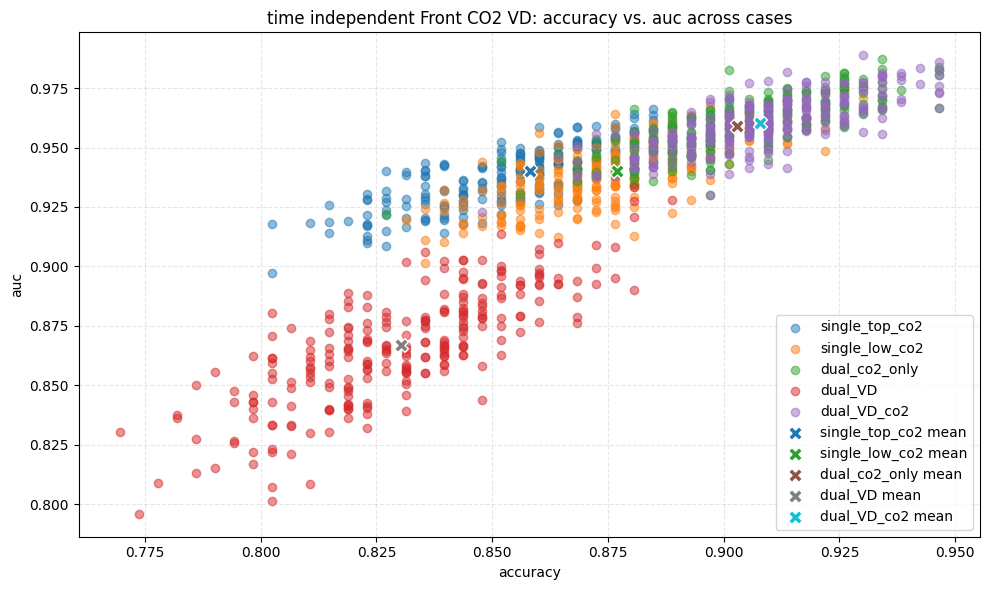

In [72]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

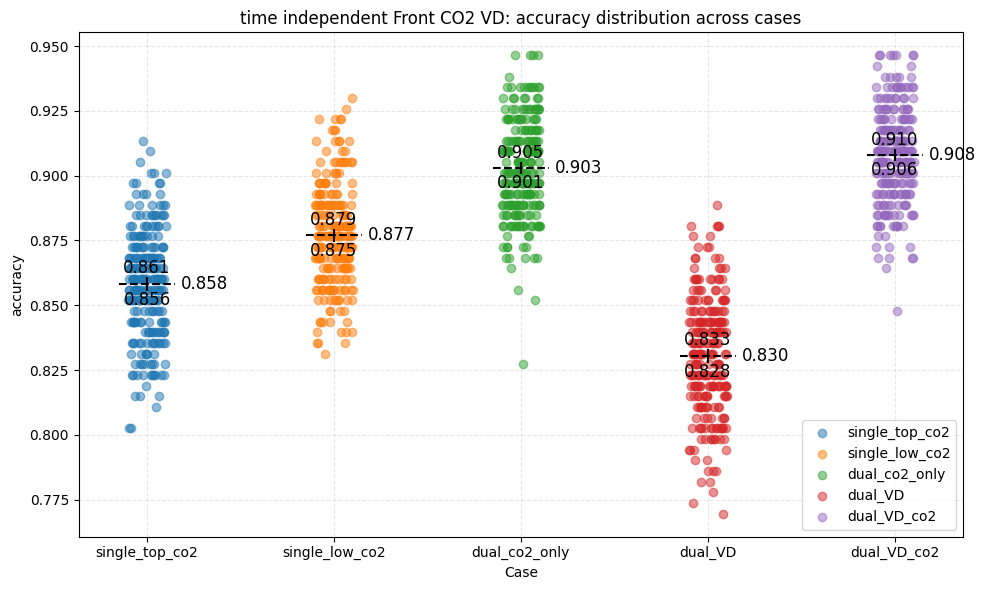

In [73]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

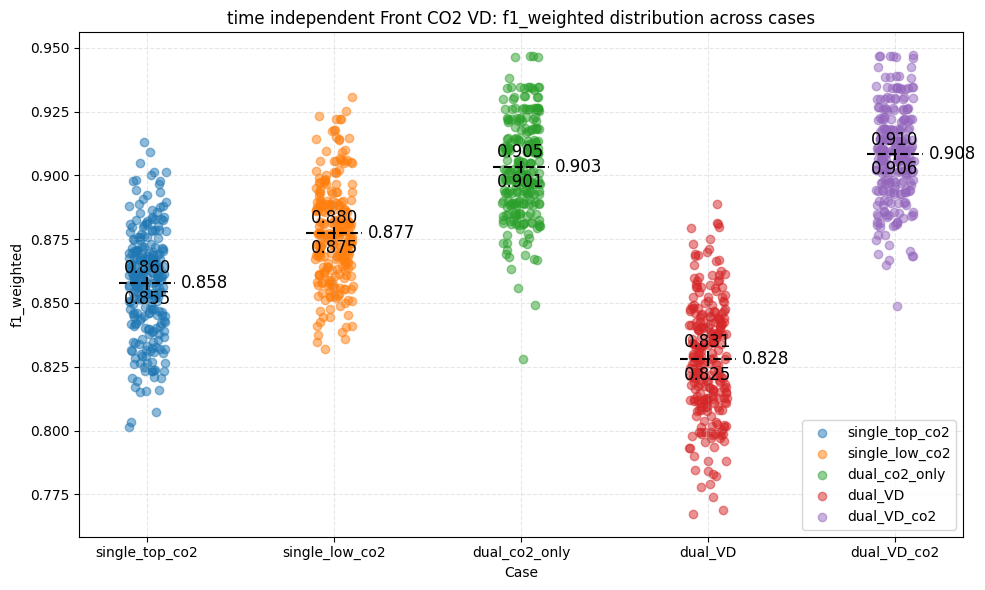

In [74]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

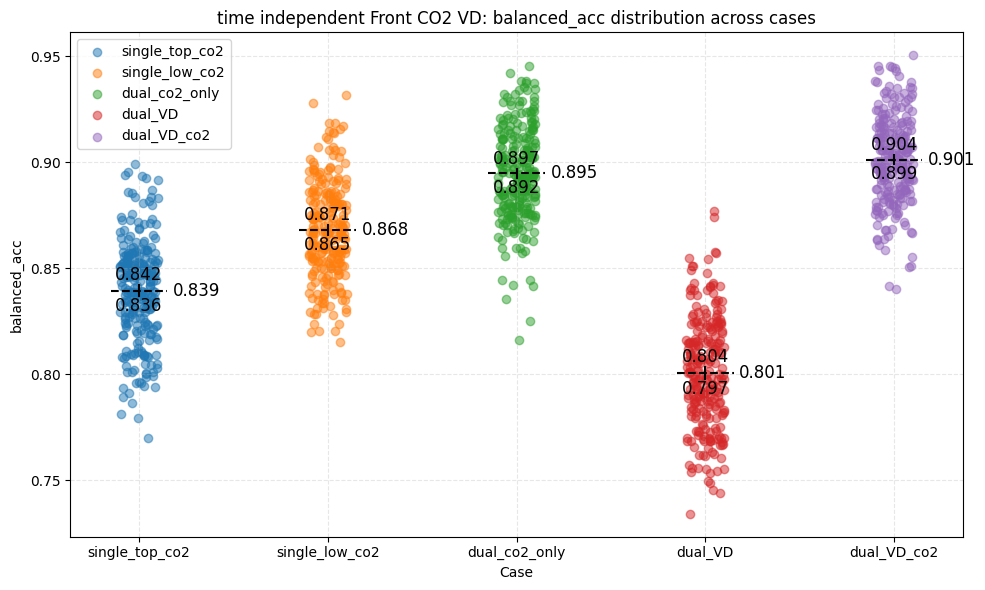

In [75]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

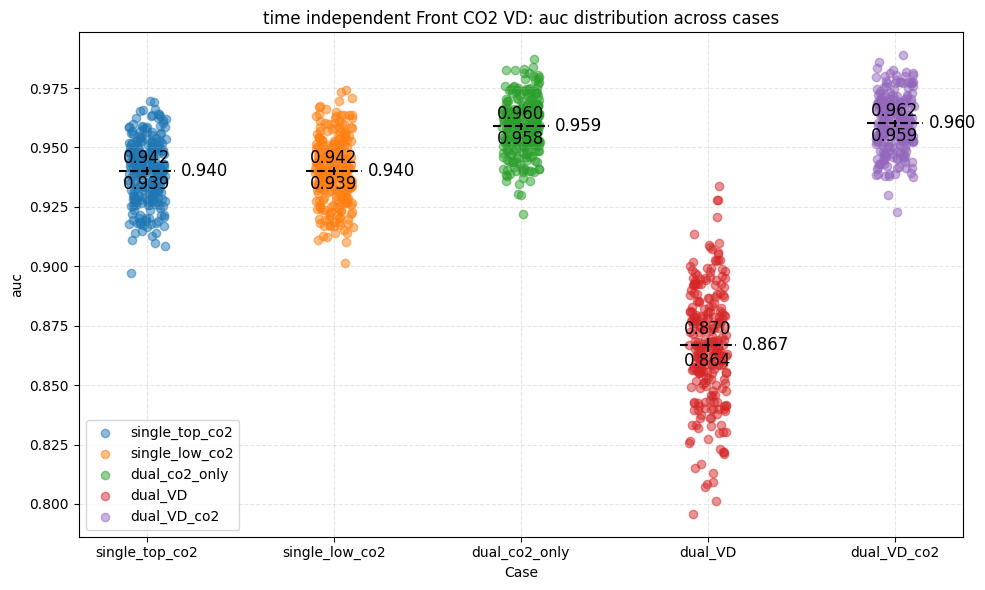

In [76]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [77]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent Front CO2 VD

=== Normality test (D’Agostino and Pearson) for accuracy ===
single_top_co2           :	p = 0.7843	→	OK normal
single_low_co2           :	p = 0.2640	→	OK normal
dual_co2_only            :	p = 0.2417	→	OK normal
dual_VD                  :	p = 0.7621	→	OK normal
dual_VD_co2              :	p = 0.7563	→	OK normal

=== Normality test (Shapiro-Wilk) for accuracy ===
single_top_co2           :	p = 0.2446	→	OK normal
single_low_co2           :	p = 0.0264	→	not normal
dual_co2_only            :	p = 0.0068	→	not normal
dual_VD                  :	p = 0.4070	→	OK normal
dual_VD_co2              :	p = 0.0656	→	OK normal

=== Normality test (Anderson-Darling) for accuracy ===
single_top_co2           :	A² = 0.7674,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 1.0773,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 1.0272,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 0.5805,	5% critical = 0.7750	→	OK normal
dual

In [78]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent Front CO2 VD

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
single_top_co2           :	p = 0.7264	→	OK normal
single_low_co2           :	p = 0.2493	→	OK normal
dual_co2_only            :	p = 0.2064	→	OK normal
dual_VD                  :	p = 0.8364	→	OK normal
dual_VD_co2              :	p = 0.7291	→	OK normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
single_top_co2           :	p = 0.5306	→	OK normal
single_low_co2           :	p = 0.1478	→	OK normal
dual_co2_only            :	p = 0.0314	→	not normal
dual_VD                  :	p = 0.8552	→	OK normal
dual_VD_co2              :	p = 0.2571	→	OK normal

=== Normality test (Anderson-Darling) for f1_weighted ===
single_top_co2           :	A² = 0.5154,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 0.5775,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.5823,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.2652,	5% critical = 0.7750	→	OK norma

In [79]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent Front CO2 VD

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
single_top_co2           :	p = 0.6776	→	OK normal
single_low_co2           :	p = 0.3356	→	OK normal
dual_co2_only            :	p = 0.1891	→	OK normal
dual_VD                  :	p = 0.5089	→	OK normal
dual_VD_co2              :	p = 0.7975	→	OK normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
single_top_co2           :	p = 0.1007	→	OK normal
single_low_co2           :	p = 0.4575	→	OK normal
dual_co2_only            :	p = 0.0467	→	not normal
dual_VD                  :	p = 0.6504	→	OK normal
dual_VD_co2              :	p = 0.6782	→	OK normal

=== Normality test (Anderson-Darling) for balanced_acc ===
single_top_co2           :	A² = 0.9714,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 0.2824,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.4411,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.2848,	5% critical = 0.7750	→	OK n

In [80]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent Front CO2 VD

=== Normality test (D’Agostino and Pearson) for auc ===
single_top_co2           :	p = 0.1233	→	OK normal
single_low_co2           :	p = 0.2371	→	OK normal
dual_co2_only            :	p = 0.5376	→	OK normal
dual_VD                  :	p = 0.3956	→	OK normal
dual_VD_co2              :	p = 0.6505	→	OK normal

=== Normality test (Shapiro-Wilk) for auc ===
single_top_co2           :	p = 0.0831	→	OK normal
single_low_co2           :	p = 0.6462	→	OK normal
dual_co2_only            :	p = 0.7268	→	OK normal
dual_VD                  :	p = 0.5264	→	OK normal
dual_VD_co2              :	p = 0.5317	→	OK normal

=== Normality test (Anderson-Darling) for auc ===
single_top_co2           :	A² = 0.7068,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 0.2241,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.2121,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.3747,	5% critical = 0.7750	→	OK normal
dual_VD_co2            

### ANOVA

In [81]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent Front CO2 VD

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2         F         p-unc      np2
  case      4 621.643564 615.43959 1.672773e-214 0.676096

Effect size (partial η², np2) = 0.6761 → large effect

=== Games-Howell post-hoc test for accuracy ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.830387 0.907918 -0.077531 0.001821 -42.565704 476.129107 1.343370e-14 -3.801456
       dual_VD  dual_co2_only 0.830387 0.902930 -0.072543 0.001853 -39.143418 483.532795 9.225953e-14 -3.495818
       dual_VD single_low_co2 0.830387 0.876938 -0.046551 0.001873 -24.849273 487.331798 6.816769e-14 -2.219238
       dual_VD single_top_co2 0.830387 0.858222 -0.027835 0.001935 -14.384569 495.149152 1.030287e-13 -1.284656
   dual_VD_co2  dual_co2_only 0.907918 0.902930  0.004988 0.001650   3.022239 497.083344 2.208328e-02  0.269910
   dual_VD_co2 single_low_co2 0.907918 0.876

In [82]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent Front CO2 VD

=== Welch ANOVA for f1_weighted ===
Source  ddof1      ddof2         F         p-unc      np2
  case      4 621.493395 637.98995 2.296782e-218 0.686512

Effect size (partial η², np2) = 0.6865 → large effect

=== Games-Howell post-hoc test for f1_weighted ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.828233 0.908213 -0.079980 0.001840 -43.459527 471.999895 7.693846e-14 -3.881281
       dual_VD  dual_co2_only 0.828233 0.903138 -0.074905 0.001875 -39.941472 480.824063 1.686429e-13 -3.567091
       dual_VD single_low_co2 0.828233 0.877435 -0.049202 0.001891 -26.016577 484.138478 3.361755e-13 -2.323487
       dual_VD single_top_co2 0.828233 0.857679 -0.029446 0.001959 -15.028279 494.067181 3.568257e-13 -1.342145
   dual_VD_co2  dual_co2_only 0.908213 0.903138  0.005075 0.001650   3.076048 496.863754 1.873093e-02  0.274715
   dual_VD_co2 single_low_co2 0.908213

In [83]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent Front CO2 VD

=== Welch ANOVA for balanced_acc ===
Source  ddof1     ddof2          F         p-unc      np2
  case      4 621.54168 756.824609 3.374971e-237 0.720966

Effect size (partial η², np2) = 0.7210 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.800534 0.901118 -0.100583 0.002098 -47.940345 472.536391 2.760014e-13 -4.281454
       dual_VD  dual_co2_only 0.800534 0.894723 -0.094189 0.002164 -43.530727 485.793736 0.000000e+00 -3.887640
       dual_VD single_low_co2 0.800534 0.867786 -0.067252 0.002184 -30.786777 488.871375 0.000000e+00 -2.749504
       dual_VD single_top_co2 0.800534 0.839307 -0.038773 0.002244 -17.280083 495.040201 1.434408e-13 -1.543249
   dual_VD_co2  dual_co2_only 0.901118 0.894723  0.006394 0.001913   3.342492 495.107408 7.919976e-03  0.298511
   dual_VD_co2 single_low_co2 0.9011

In [84]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent Front CO2 VD

=== Welch ANOVA for auc ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 616.742206 870.785966 5.405711e-252 0.829512

Effect size (partial η², np2) = 0.8295 → large effect

=== Games-Howell post-hoc test for auc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.866814 0.960209 -0.093395 0.001684 -55.472210 355.266377 0.000000e+00 -4.954109
       dual_VD  dual_co2_only 0.866814 0.958970 -0.092156 0.001691 -54.494758 359.895111 1.517675e-13 -4.866815
       dual_VD single_low_co2 0.866814 0.940249 -0.073436 0.001757 -41.789100 398.476713 1.022515e-13 -3.732099
       dual_VD single_top_co2 0.866814 0.940251 -0.073437 0.001742 -42.157112 390.001029 1.909584e-13 -3.764965
   dual_VD_co2  dual_co2_only 0.960209 0.958970  0.001239 0.001031   1.201773 497.720805 7.503846e-01  0.107328
   dual_VD_co2 single_low_co2 0.960209 0.940249  0.0

## Time series - Front

In [85]:
model = "time series Front CO2 VD"
single_top_co2 = pd.read_csv("../../analysis_sensor_position/_timeseries_results_raw/case_room1_fronttop_state_timeseries_co2.csv")
single_low_co2 = pd.read_csv("../../analysis_sensor_position/_timeseries_results_raw/case_room1_frontlow_state_timeseries_co2.csv")
dual_co2_only = pd.read_csv("../_timeseries_results_raw/case_room1_front_state_timeseries_co2only.csv")
dual_VD = pd.read_csv("../_timeseries_results_raw/case_room1_front_state_timeseries_VD.csv")
dual_VD_co2 = pd.read_csv("../_timeseries_results_raw/case_room1_front_state_timeseries_VDco2.csv")

In [86]:
single_top_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.857863,0.041123,0.602740,0.845890,0.858447,0.880137,0.922374
f1,250.0,0.815590,0.081431,0.155340,0.803035,0.820809,0.853157,0.909091
balanced_acc,250.0,0.846643,0.050647,0.531667,0.832452,0.846499,0.873106,0.922586
auc,250.0,0.926673,0.011267,0.885228,0.920704,0.927764,0.934397,0.950188
feature_importance.fronttop_CO2_scaled,250.0,0.268974,0.132808,0.004566,0.159475,0.272603,0.387443,0.538356
feature_importance.fronttop_CO2_fd1_scaled,250.0,0.026544,0.032358,-0.021918,0.007420,0.017580,0.035502,0.258904
feature_importance.fronttop_CO2_fd2_scaled,250.0,0.025289,0.034408,-0.029680,0.004566,0.014840,0.035845,0.227397
feature_importance.fronttop_CO2_fd3_scaled,250.0,0.020327,0.034975,-0.053881,0.002283,0.012557,0.030594,0.273059


In [87]:
single_low_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.801582,0.045333,0.586667,0.768889,0.795556,0.844444,0.875556
f1,250.0,0.751723,0.085187,0.000000,0.732838,0.762140,0.800000,0.840909
balanced_acc,250.0,0.794235,0.048523,0.496241,0.770595,0.795235,0.831879,0.864580
auc,250.0,0.885157,0.019732,0.780566,0.872160,0.886605,0.899620,0.926773
feature_importance.frontlow_CO2_scaled,250.0,0.188380,0.082710,-0.010222,0.138667,0.212222,0.254667,0.315111
feature_importance.frontlow_CO2_fd1_scaled,250.0,0.054852,0.048882,-0.036444,0.022667,0.040889,0.073778,0.247111
feature_importance.frontlow_CO2_fd2_scaled,250.0,0.056907,0.044525,-0.018222,0.023556,0.049333,0.084222,0.254667
feature_importance.frontlow_CO2_fd3_scaled,250.0,0.055596,0.051455,-0.033333,0.018222,0.043111,0.082111,0.237778


In [88]:
dual_co2_only.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.806933,0.030298,0.750000,0.783333,0.804167,0.829167,0.870833
f1,250.0,0.770229,0.026446,0.602941,0.751220,0.770642,0.789530,0.829268
balanced_acc,250.0,0.813230,0.021934,0.712691,0.796857,0.814483,0.829906,0.867362
auc,250.0,0.896487,0.008524,0.871328,0.890717,0.896556,0.901954,0.920682
feature_importance.frontlow_CO2_scaled,250.0,0.093405,0.032640,-0.010833,0.082917,0.100000,0.114583,0.142083
feature_importance.frontlow_CO2_fd1_scaled,250.0,0.030693,0.017231,-0.006250,0.019167,0.031250,0.041562,0.085000
feature_importance.frontlow_CO2_fd2_scaled,250.0,0.023612,0.014765,-0.005000,0.013854,0.023333,0.031250,0.070000
feature_importance.frontlow_CO2_fd3_scaled,250.0,0.018830,0.013111,-0.008333,0.009583,0.017500,0.027083,0.066667


In [89]:
dual_VD.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.769173,0.031421,0.608889,0.752222,0.773333,0.791111,0.831111
f1,250.0,0.693610,0.057500,0.424242,0.666667,0.705202,0.736856,0.781609
balanced_acc,250.0,0.750423,0.038319,0.607061,0.729793,0.756334,0.779329,0.816934
auc,250.0,0.865921,0.016870,0.708483,0.859819,0.865765,0.873631,0.907323
feature_importance.front_CO2_vd_scaled,250.0,0.005022,0.021090,-0.103111,-0.008889,0.007556,0.019556,0.053778
feature_importance.front_CO2_vd_fd1_scaled,250.0,0.058533,0.017814,0.009333,0.045889,0.057778,0.070556,0.119111
feature_importance.front_CO2_vd_fd2_scaled,250.0,0.084437,0.020017,-0.002222,0.073889,0.086667,0.097333,0.128889
feature_importance.front_CO2_vd_fd3_scaled,250.0,0.095492,0.019985,-0.015111,0.083778,0.095111,0.108333,0.140000


In [90]:
dual_VD_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.823961,0.071638,0.555556,0.787440,0.840580,0.869565,0.927536
f1,250.0,0.802226,0.135449,0.000000,0.783730,0.825964,0.856787,0.920635
balanced_acc,250.0,0.826796,0.074702,0.500000,0.801359,0.839674,0.870380,0.929348
auc,250.0,0.921263,0.046750,0.312949,0.913800,0.927647,0.940147,0.978733
feature_importance.front_CO2_vd_scaled,250.0,-0.015973,0.022856,-0.088406,-0.032246,-0.013768,-0.001449,0.054106
feature_importance.front_CO2_vd_fd1_scaled,250.0,0.008015,0.010700,-0.052174,0.001449,0.006763,0.013406,0.051691
feature_importance.front_CO2_vd_fd2_scaled,250.0,0.012410,0.013988,-0.057971,0.003382,0.012319,0.020290,0.057971
feature_importance.front_CO2_vd_fd3_scaled,250.0,0.011314,0.014191,-0.042512,0.002899,0.010628,0.019807,0.052174


In [91]:
single_top_co2['case'] = 'single_top_co2'
single_low_co2['case'] = 'single_low_co2'
dual_co2_only['case'] = 'dual_co2_only'
dual_VD['case'] = 'dual_VD'
dual_VD_co2['case'] = 'dual_VD_co2'

metrics = ["case", "accuracy", "f1", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        single_top_co2[metrics],
        single_low_co2[metrics],
        dual_co2_only[metrics],
        dual_VD[metrics],
        dual_VD_co2[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1250 non-null   object 
 1   accuracy      1250 non-null   float64
 2   f1            1250 non-null   float64
 3   balanced_acc  1250 non-null   float64
 4   auc           1250 non-null   float64
dtypes: float64(4), object(1)
memory usage: 49.0+ KB


In [92]:
case_order = ['single_top_co2', 'single_low_co2', 'dual_co2_only', 'dual_VD', 'dual_VD_co2']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,single_top_co2,single_top_co2,single_top_co2,single_top_co2,single_top_co2
accuracy,0.899543,0.844749,0.881279,0.86758,0.812785
f1,0.880435,0.8,0.867347,0.837989,0.805687
balanced_acc,0.89691,0.830195,0.887153,0.860365,0.828098
auc,0.915098,0.939233,0.924427,0.929476,0.920575
x,0,0,0,0,0
x_jitter,-0.03391,0.005066,0.092532,-0.018324,0.027415


### plot

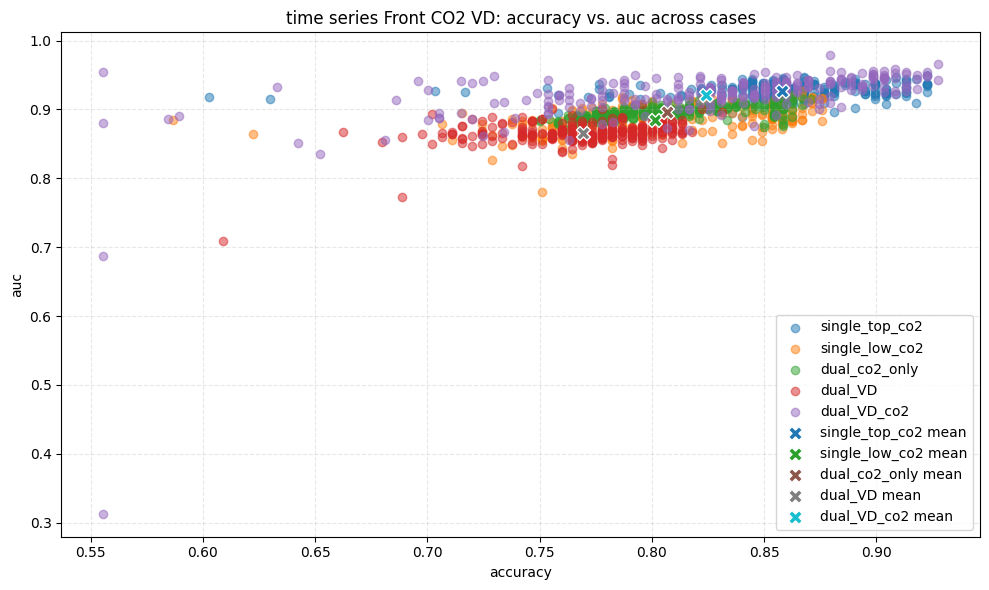

In [93]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

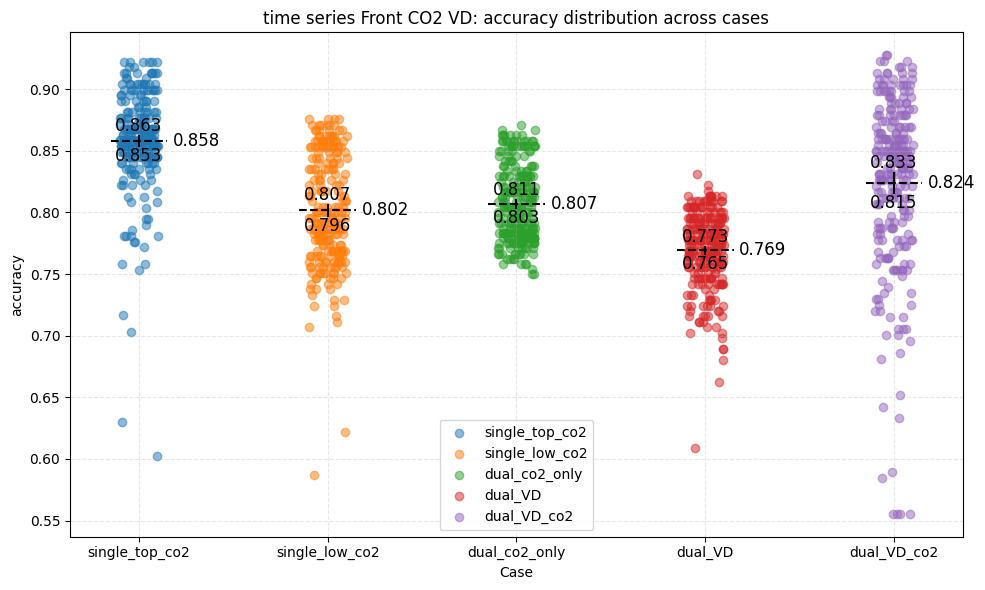

In [94]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

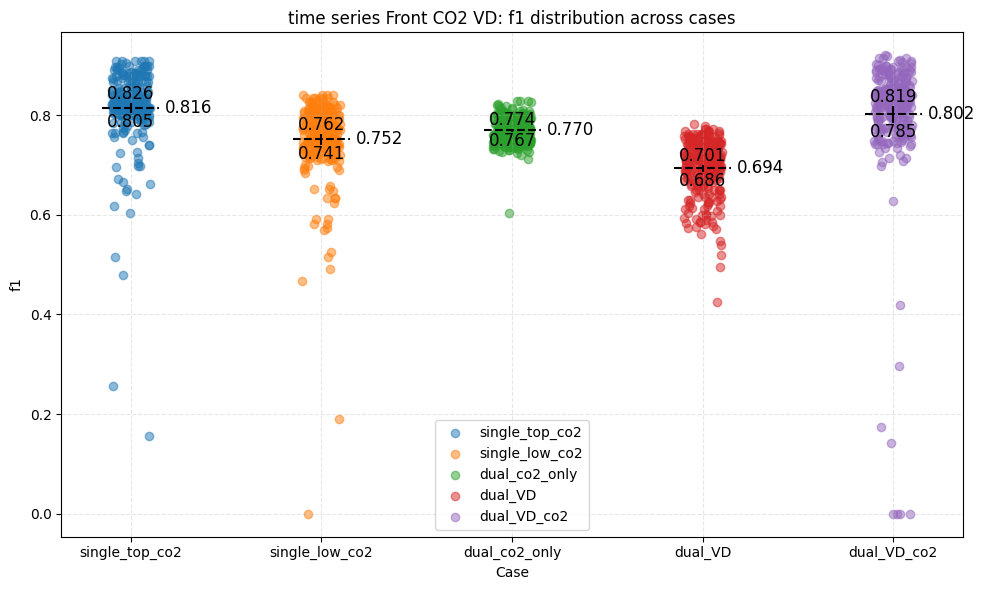

In [95]:
# plot f1 score
metric = "f1"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

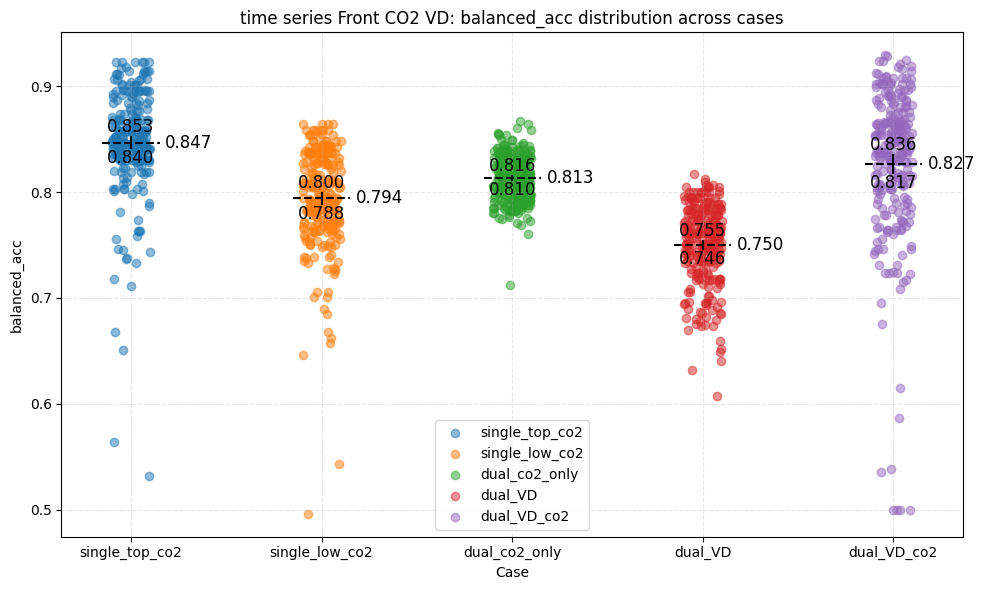

In [96]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

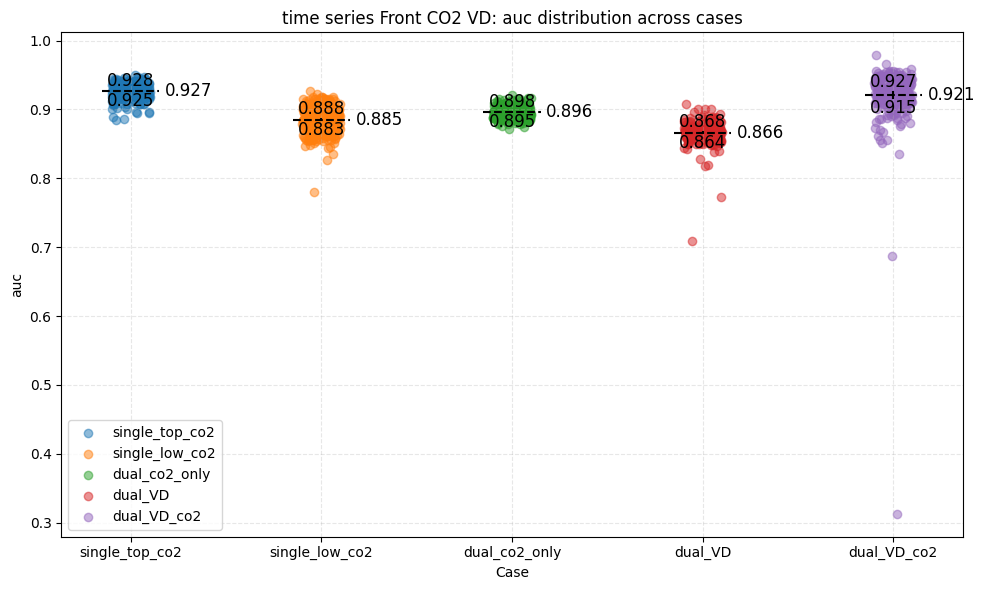

In [97]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [98]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time series Front CO2 VD

=== Normality test (D’Agostino and Pearson) for accuracy ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
single_top_co2           :	A² = 8.4902,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 3.0841,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 3.7561,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 2.9654,	5% critical = 0.7750	→	not normal

In [99]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1',
    group_order=case_order
)

time series Front CO2 VD

=== Normality test (D’Agostino and Pearson) for f1 ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for f1 ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for f1 ===
single_top_co2           :	A² = 17.6390,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 16.8882,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 0.8068,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 4.6470,	5% critical = 0.7750	→	not normal
dual_VD_co2    

In [100]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time series Front CO2 VD

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0147	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0027	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for balanced_acc ===
single_top_co2           :	A² = 8.5218,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 3.7394,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 0.6835,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 2.9373,	5% critical = 0.7750	→

In [101]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time series Front CO2 VD

=== Normality test (D’Agostino and Pearson) for auc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.7942	→	OK normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.7705	→	OK normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
single_top_co2           :	A² = 2.0979,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 0.8409,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 0.3745,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 9.4978,	5% critical = 0.7750	→	not normal
dual_VD_co2      

### ANOVA

In [102]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time series Front CO2 VD

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 613.099158 188.892875 2.071475e-105 0.281829

Effect size (partial η², np2) = 0.2818 → large effect

=== Games-Howell post-hoc test for accuracy ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.769173 0.823961 -0.054788 0.004947 -11.074026 341.382324 0.000000e+00 -0.988999
       dual_VD  dual_co2_only 0.769173 0.806933 -0.037760 0.002761 -13.678223 497.342105 0.000000e+00 -1.221574
       dual_VD single_low_co2 0.769173 0.801582 -0.032409 0.003488  -9.290348 443.380099 1.020295e-13 -0.829702
       dual_VD single_top_co2 0.769173 0.857863 -0.088690 0.003273 -27.096109 465.828908 0.000000e+00 -2.419898
   dual_VD_co2  dual_co2_only 0.823961 0.806933  0.017028 0.004919   3.461442 335.315379 5.454105e-03  0.309134
   dual_VD_co2 single_low_co2 0.823961 0.801582

In [103]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1'
)

time series Front CO2 VD

=== Welch ANOVA for f1 ===
Source  ddof1      ddof2          F        p-unc      np2
  case      4 568.126659 127.510577 1.239660e-77 0.203663

Effect size (partial η², np2) = 0.2037 → large effect

=== Games-Howell post-hoc test for f1 ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.693610 0.802226 -0.108615 0.009306 -11.670971 335.922093 7.105427e-15 -1.042310
       dual_VD  dual_co2_only 0.693610 0.770229 -0.076619 0.004003 -19.141448 349.831259 1.987299e-14 -1.709483
       dual_VD single_low_co2 0.693610 0.751723 -0.058113 0.006500  -8.940218 436.888029 2.210454e-13 -0.798433
       dual_VD single_top_co2 0.693610 0.815590 -0.121980 0.006305 -19.347622 447.865127 4.574119e-14 -1.727896
   dual_VD_co2  dual_co2_only 0.802226 0.770229  0.031996 0.008728   3.665816 267.956405 2.730932e-03  0.327387
   dual_VD_co2 single_low_co2 0.802226 0.751723  0.050502 0.0

In [104]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time series Front CO2 VD

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 591.893776 185.276023 7.451774e-103 0.301946

Effect size (partial η², np2) = 0.3019 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.750423 0.826796 -0.076373 0.005310 -14.383187 371.550868 7.949197e-14 -1.284533
       dual_VD  dual_co2_only 0.750423 0.813230 -0.062808 0.002792 -22.492000 396.353623 1.393330e-13 -2.008714
       dual_VD single_low_co2 0.750423 0.794235 -0.043812 0.003910 -11.204020 472.605678 1.896261e-13 -1.000608
       dual_VD single_top_co2 0.750423 0.846643 -0.096220 0.004017 -23.955180 463.714183 9.847678e-14 -2.139388
   dual_VD_co2  dual_co2_only 0.826796 0.813230  0.013565 0.004924   2.754928 291.618004 4.866966e-02  0.246037
   dual_VD_co2 single_low_co2 0.826796 

In [105]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time series Front CO2 VD

=== Welch ANOVA for auc ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 596.268842 661.581631 1.332885e-217 0.455954

Effect size (partial η², np2) = 0.4560 → large effect

=== Games-Howell post-hoc test for auc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.865921 0.921263 -0.055342 0.003143 -17.606179 312.767315 9.048318e-14 -1.572372
       dual_VD  dual_co2_only 0.865921 0.896487 -0.030565 0.001195 -25.568608 368.373598 4.574119e-14 -2.283480
       dual_VD single_low_co2 0.865921 0.885157 -0.019236 0.001642 -11.715780 486.248860 0.000000e+00 -1.046312
       dual_VD single_top_co2 0.865921 0.926673 -0.060751 0.001283 -47.349892 434.276218 3.940182e-13 -4.228722
   dual_VD_co2  dual_co2_only 0.921263 0.896487  0.024777 0.003005   8.243839 265.539751 1.474376e-13  0.736240
   dual_VD_co2 single_low_co2 0.921263 0.885157  0.036106